# PowerNap Comparable Model Evaluation

This notebook is the project-level judge. It does not train models. It reads standardized prediction CSVs from `model_predictions/`, validates them against the shared forecasting contract, computes comparable metrics, and renders comparison graphs inline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

TARGET_COL = "carbon_intensity"
UNIT = "gCO2eq/kWh"
HORIZONS = [1, 6, 24]
REGIONS = ["california", "illinois", "texas", "virginia"]
PREDICTION_DIR = Path("model_predictions")

REQUIRED_COLUMNS = [
    "datetime", "target_datetime", "region", "horizon", "model",
    "y_true", "y_pred", "split_type", "split", "holdout_region",
]
CORE_COLUMNS = ["datetime", "target_datetime", "region", "horizon", "model", "y_true", "y_pred", "split_type", "split", "holdout_region"]

print("Target:", TARGET_COL)
print("Unit:", UNIT)
print("Horizons:", HORIZONS)
print("Prediction files directory:", PREDICTION_DIR)


Target: carbon_intensity
Unit: gCO2eq/kWh
Horizons: [1, 6, 24]
Prediction files directory: model_predictions


## Forecasting Contract

All models are compared on the same task: use information available up to time `t` to predict `carbon_intensity` at `t+horizon`. Ridge/RF use tabular lag features. LSTM uses a 24-hour sequence ending at `datetime`. The input shapes differ, but the target, horizons, splits, and metrics are shared.


In [2]:
contract = pd.DataFrame([
    {"Field": "Target", "Value": TARGET_COL},
    {"Field": "Unit", "Value": UNIT},
    {"Field": "Horizons", "Value": ", ".join(f"{h}h" for h in HORIZONS)},
    {"Field": "Temporal split", "Value": "chronological_time: regional model, early 70% train, next 10% val, final 20% test"},
    {"Field": "Region split", "Value": "leave_one_region_out: train on 3 regions, test held-out 4th"},
    {"Field": "Ridge/RF input", "Value": "one row at t with weather, lag, time, and energy-mix features"},
    {"Field": "LSTM input", "Value": "24-hour sequence ending at t"},
])
display(contract)


,Field,Value
0,Target,carbon_intensity
1,Unit,gCO2eq/kWh
2,Horizons,"1h, 6h, 24h"
3,Temporal split,"chronological_time: regional model, early 70% ..."
4,Region split,"leave_one_region_out: train on 3 regions, test..."
5,Ridge/RF input,"one row at t with weather, lag, time, and ener..."
6,LSTM input,24-hour sequence ending at t


## Load Prediction CSVs

Run the modeling notebooks first so this directory contains prediction files. The evaluation notebook can work with a subset while the team is still producing LSTM exports, but the coverage table below will make missing model/horizon/split combinations visible.


### Current LSTM Inclusion Note

The LSTM prediction files now come from the project notebooks using the shared contract: `lstm_regional_predictions.csv` covers chronological temporal generalization for all regions and horizons, and `lstm_global_predictions.csv` covers leave-one-region-out regional generalization for all held-out regions and horizons. The coverage table below should show Ridge, Random Forest, and LSTM rows for `1h`, `6h`, and `24h` where the model family is applicable.


In [3]:
prediction_files = sorted(PREDICTION_DIR.glob("*.csv")) if PREDICTION_DIR.exists() else []
prediction_files = [p for p in prediction_files if p.name.endswith("_predictions.csv")]

if not prediction_files:
    raise FileNotFoundError(
        "No prediction CSVs found. Run the modeling notebooks first so model_predictions/*_predictions.csv exists."
    )

frames = []
for path in prediction_files:
    frame = pd.read_csv(path)
    frame["source_file"] = path.name
    frames.append(frame)

predictions = pd.concat(frames, ignore_index=True)
print("Loaded files:", [p.name for p in prediction_files])
print("Prediction rows:", len(predictions))
display(predictions.head())


Loaded files: ['lstm_global_predictions.csv', 'lstm_regional_predictions.csv', 'ridge_rf_predictions.csv']
Prediction rows: 376276


,datetime,target_datetime,region,horizon,model,y_true,y_pred,split_type,split,holdout_region,source_file
0,2023-01-02 23:00:00,2023-01-03 00:00:00,california,1,lstm_global,256.63998,271.93967,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
1,2023-01-02 23:00:00,2023-01-03 05:00:00,california,6,lstm_global,244.64000,244.32474,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
2,2023-01-02 23:00:00,2023-01-03 23:00:00,california,24,lstm_global,238.62999,252.43806,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
3,2023-01-03 00:00:00,2023-01-03 01:00:00,california,1,lstm_global,252.96999,287.98440,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv
4,2023-01-03 00:00:00,2023-01-03 06:00:00,california,6,lstm_global,255.12001,244.53683,leave_one_region_out,held_out_california,california,lstm_global_predictions.csv


## Validate Prediction Files


In [4]:
def validate_predictions(predictions):
    errors = []
    missing = sorted(set(REQUIRED_COLUMNS) - set(predictions.columns))
    if missing:
        errors.append(f"Missing required columns: {missing}")
        return errors

    for col in ["datetime", "target_datetime"]:
        predictions[col] = pd.to_datetime(predictions[col], errors="coerce")

    null_counts = predictions[CORE_COLUMNS].isna().sum()
    bad_nulls = null_counts[null_counts > 0]
    if not bad_nulls.empty:
        errors.append("Null values in required columns: " + bad_nulls.to_dict().__repr__())

    invalid_horizons = sorted(set(predictions["horizon"].dropna().astype(int)) - set(HORIZONS))
    if invalid_horizons:
        errors.append(f"Invalid horizons found: {invalid_horizons}")

    expected_target_datetime = predictions["datetime"] + pd.to_timedelta(predictions["horizon"].astype(int), unit="h")
    mismatched_datetime = predictions["target_datetime"].ne(expected_target_datetime)
    if mismatched_datetime.any():
        sample = predictions.loc[mismatched_datetime, ["source_file", "datetime", "target_datetime", "horizon"]].head()
        errors.append("target_datetime must equal datetime + horizon hours. Sample:\n" + sample.to_string(index=False))

    duplicate_cols = ["model", "split_type", "split", "holdout_region", "region", "horizon", "datetime"]
    duplicate_count = predictions.duplicated(duplicate_cols).sum()
    if duplicate_count:
        errors.append(f"Duplicate prediction rows for {duplicate_cols}: {duplicate_count}")

    valid_split_types = {"chronological_time", "leave_one_region_out"}
    invalid_splits = sorted(set(predictions["split_type"].dropna()) - valid_split_types)
    if invalid_splits:
        errors.append(f"Invalid split_type values: {invalid_splits}")

    region_values = set(predictions["region"].dropna())
    invalid_regions = sorted(region_values - set(REGIONS))
    if invalid_regions:
        errors.append(f"Invalid regions found: {invalid_regions}")

    dataset = pd.read_csv("full_dataset_featured.csv", parse_dates=["datetime"])
    truth = dataset[["datetime", "region", TARGET_COL]].rename(columns={"datetime": "target_datetime", TARGET_COL: "dataset_y_true"})
    merged = predictions.merge(truth, on=["target_datetime", "region"], how="left")
    missing_truth = merged["dataset_y_true"].isna().sum()
    if missing_truth:
        errors.append(f"Could not find dataset y_true for {missing_truth} prediction rows")
    else:
        max_diff = np.max(np.abs(merged["y_true"].astype(float) - merged["dataset_y_true"].astype(float)))
        if max_diff > 1e-3:
            errors.append(f"y_true does not match full_dataset_featured.csv; max difference {max_diff:.6f}")

    return errors

validation_errors = validate_predictions(predictions)
if validation_errors:
    print("Validation failed:")
    for err in validation_errors:
        print("-", err)
    raise ValueError("Prediction validation failed. Fix model export CSVs before comparing metrics.")

print("Validation passed.")


Validation passed.


## Coverage Check

This table shows which models have produced rows for each split and horizon. Missing rows are not a validation failure while work is in progress, but they indicate incomplete comparability.


In [5]:
coverage = (
    predictions.groupby(["model", "split_type", "horizon"])
    .size()
    .reset_index(name="rows")
    .sort_values(["model", "split_type", "horizon"])
)
display(coverage)

coverage_pivot = coverage.pivot_table(index=["model", "split_type"], columns="horizon", values="rows", fill_value=0)
display(coverage_pivot)


,model,split_type,horizon,rows
0,lstm_global,leave_one_region_out,1,34756
1,lstm_global,leave_one_region_out,6,34756
2,lstm_global,leave_one_region_out,24,34756
3,lstm_regional,chronological_time,1,6896
4,lstm_regional,chronological_time,6,6896
5,lstm_regional,chronological_time,24,6896
6,random_forest,chronological_time,1,6992
7,random_forest,chronological_time,6,6988
8,random_forest,chronological_time,24,6972
9,random_forest,leave_one_region_out,1,34940


horizon                                  1        6        24
model         split_type                                     
lstm_global   leave_one_region_out  34756.0  34756.0  34756.0
lstm_regional chronological_time     6896.0   6896.0   6896.0
random_forest chronological_time     6992.0   6988.0   6972.0
              leave_one_region_out  34940.0  34920.0  34848.0
ridge         chronological_time     6992.0   6988.0   6972.0
              leave_one_region_out  34940.0  34920.0  34848.0

## Compute Metrics


In [6]:
def metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_pred - y_true
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": float(np.mean(residual)),
    }

rows = []
for keys, group in predictions.groupby(["split_type", "model", "horizon", "region"]):
    row = dict(zip(["split_type", "model", "horizon", "region"], keys))
    row["n"] = len(group)
    row.update(metric_row(group["y_true"], group["y_pred"]))
    rows.append(row)

metrics = pd.DataFrame(rows)
macro_rows = []
for keys, group in metrics.groupby(["split_type", "model", "horizon"]):
    row = dict(zip(["split_type", "model", "horizon"], keys))
    row["region"] = "macro_average"
    row["n"] = group["n"].sum()
    for col in ["MAE", "RMSE", "R2", "Bias"]:
        row[col] = group[col].mean()
    macro_rows.append(row)

metrics = pd.concat([metrics, pd.DataFrame(macro_rows)], ignore_index=True)
metrics["horizon_label"] = metrics["horizon"].astype(str) + "h"
metrics = metrics.sort_values(["split_type", "horizon", "model", "region"])
display(metrics)


,split_type,model,horizon,region,n,MAE,RMSE,R2,Bias,horizon_label
0,chronological_time,lstm_regional,1,california,1724,15.593023,18.681554,0.893554,-13.888842,1h
1,chronological_time,lstm_regional,1,illinois,1724,7.388410,9.339642,0.966499,0.210837,1h
72,chronological_time,lstm_regional,1,macro_average,6896,11.876402,14.928740,0.920118,-7.620078,1h
2,chronological_time,lstm_regional,1,texas,1724,20.020452,25.990442,0.891217,-16.318354,1h
3,chronological_time,lstm_regional,1,virginia,1724,4.503722,5.703321,0.929204,-0.483951,1h
...,...,...,...,...,...,...,...,...,...,...
68,leave_one_region_out,ridge,24,california,8712,42.356348,51.878159,0.337129,32.383494,24h
69,leave_one_region_out,ridge,24,illinois,8712,41.855745,51.391084,0.278112,-27.581971,24h
89,leave_one_region_out,ridge,24,macro_average,34848,44.673184,54.580115,-0.184818,12.185234,24h
70,leave_one_region_out,ridge,24,texas,8712,50.691508,65.697025,0.220534,0.812911,24h


## Generalization Gap

For models with both temporal and leave-one-region-out rows under the same model name, compute `leave_one_region_out_MAE - chronological_time_MAE`. For LSTM, if temporal rows use `lstm_regional` and region-holdout rows use `lstm_global`, the notebook also maps both to the `lstm` family.


In [7]:
def model_family(model):
    if model in {"lstm_regional", "lstm_global"}:
        return "lstm"
    return model

metrics_with_family = metrics[metrics["region"] != "macro_average"].copy()
metrics_with_family["model_family"] = metrics_with_family["model"].map(model_family)

temporal = metrics_with_family[metrics_with_family["split_type"] == "chronological_time"].copy()
regional = metrics_with_family[metrics_with_family["split_type"] == "leave_one_region_out"].copy()

gaps = regional.merge(
    temporal,
    on=["model_family", "horizon", "region"],
    suffixes=("_region_holdout", "_temporal"),
)

if not gaps.empty:
    gaps = gaps[["model_family", "horizon", "region", "MAE_temporal", "MAE_region_holdout"]].copy()
    gaps["region_gap"] = gaps["MAE_region_holdout"] - gaps["MAE_temporal"]
    macro_gaps = gaps.groupby(["model_family", "horizon"], as_index=False).agg(
        MAE_temporal=("MAE_temporal", "mean"),
        MAE_region_holdout=("MAE_region_holdout", "mean"),
        region_gap=("region_gap", "mean"),
    )
    macro_gaps["region"] = "macro_average"
    display(pd.concat([gaps, macro_gaps], ignore_index=True).sort_values(["horizon", "model_family", "region"]))
else:
    print("No models currently have both temporal and regional rows for gap computation.")
    macro_gaps = pd.DataFrame()


,model_family,horizon,region,MAE_temporal,MAE_region_holdout,region_gap
0,lstm,1,california,15.593023,32.610110,17.017086
1,lstm,1,illinois,7.388410,50.390881,43.002471
36,lstm,1,macro_average,11.876402,31.133693,19.257291
2,lstm,1,texas,20.020452,18.961704,-1.058749
3,lstm,1,virginia,4.503722,22.572077,18.068355
4,random_forest,1,california,10.614805,79.518357,68.903553
5,random_forest,1,illinois,11.862856,58.235890,46.373034
39,random_forest,1,macro_average,13.076922,51.836770,38.759848
6,random_forest,1,texas,24.581183,41.954564,17.373381
7,random_forest,1,virginia,5.248844,27.638269,22.389426


## Graph: MAE By Model And Horizon


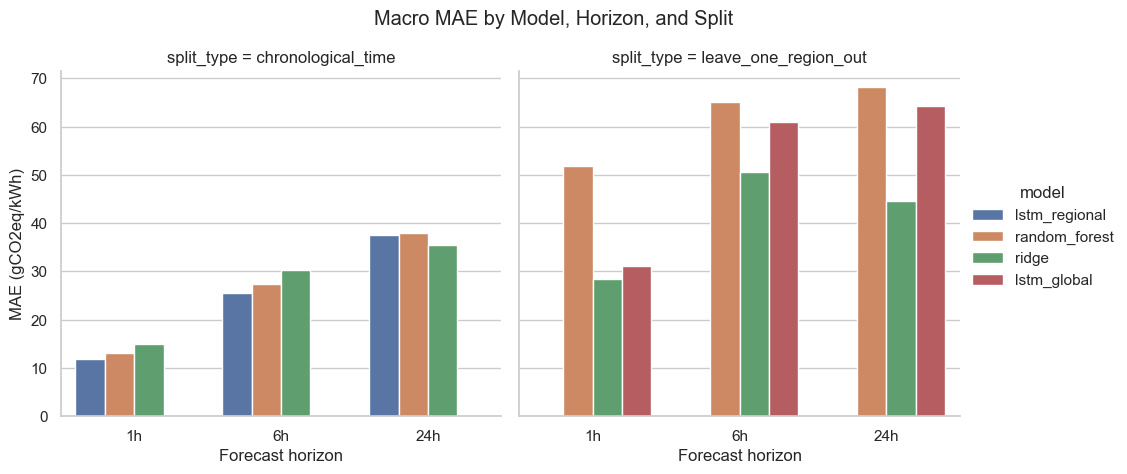

In [8]:
macro = metrics[metrics["region"] == "macro_average"].copy()
if not macro.empty:
    g = sns.catplot(
        data=macro,
        x="horizon_label",
        y="MAE",
        hue="model",
        col="split_type",
        kind="bar",
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon", f"MAE ({UNIT})")
    g.fig.suptitle("Macro MAE by Model, Horizon, and Split", y=1.05)
    plt.show()


## Graph: R2 By Model And Horizon

R2 is computed with the same grouping as MAE. Higher is better; values below zero mean the model is worse than predicting the mean for that evaluation group.

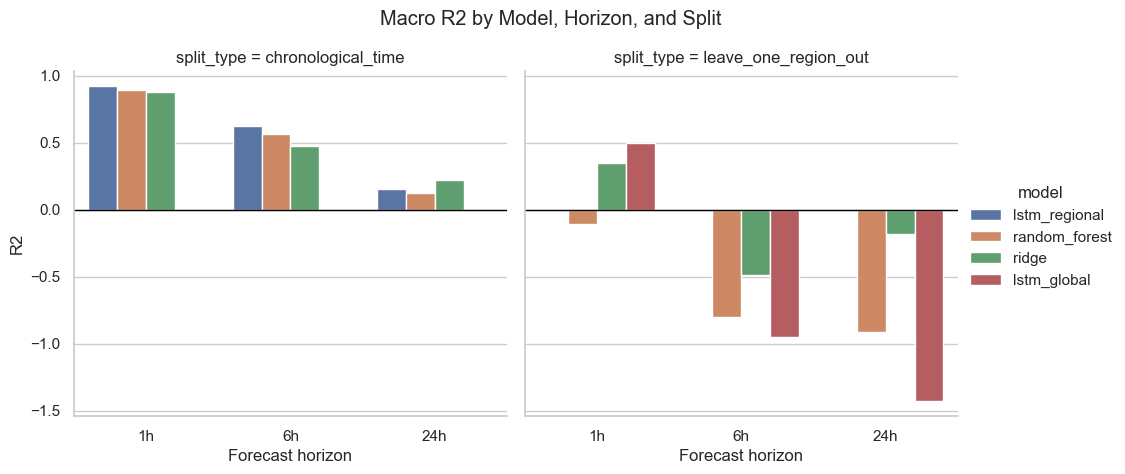

In [9]:
macro = metrics[metrics["region"] == "macro_average"].copy()
if not macro.empty:
    g = sns.catplot(
        data=macro,
        x="horizon_label",
        y="R2",
        hue="model",
        col="split_type",
        kind="bar",
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon", "R2")
    g.fig.suptitle("Macro R2 by Model, Horizon, and Split", y=1.05)
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
    plt.show()


## Graph: Horizon Trend Lines

These line charts show how macro-average MAE and R2 change as the forecast horizon gets farther out.

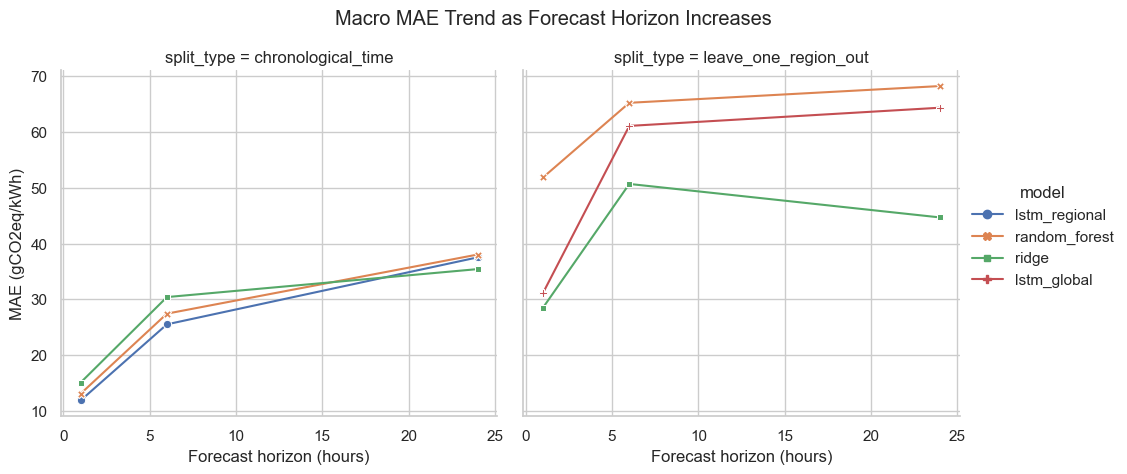

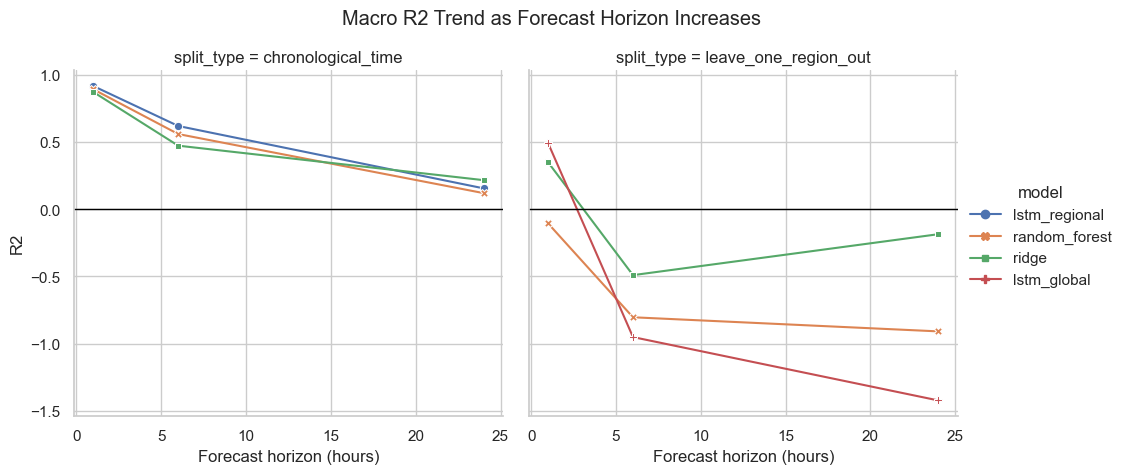

In [10]:
macro = metrics[metrics["region"] == "macro_average"].copy()
if not macro.empty:
    g = sns.relplot(
        data=macro,
        x="horizon",
        y="MAE",
        hue="model",
        style="model",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon (hours)", f"MAE ({UNIT})")
    g.fig.suptitle("Macro MAE Trend as Forecast Horizon Increases", y=1.05)
    plt.show()

    g = sns.relplot(
        data=macro,
        x="horizon",
        y="R2",
        hue="model",
        style="model",
        col="split_type",
        kind="line",
        markers=True,
        dashes=False,
        height=4.5,
        aspect=1.1,
    )
    g.set_axis_labels("Forecast horizon (hours)", "R2")
    g.fig.suptitle("Macro R2 Trend as Forecast Horizon Increases", y=1.05)
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
    plt.show()


## Graph: MAE By Region


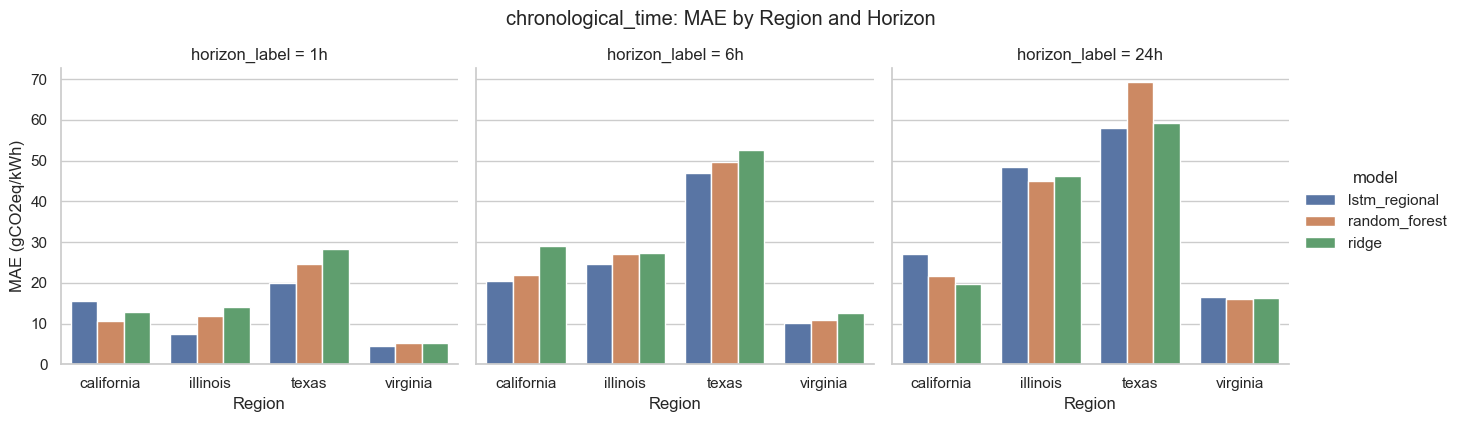

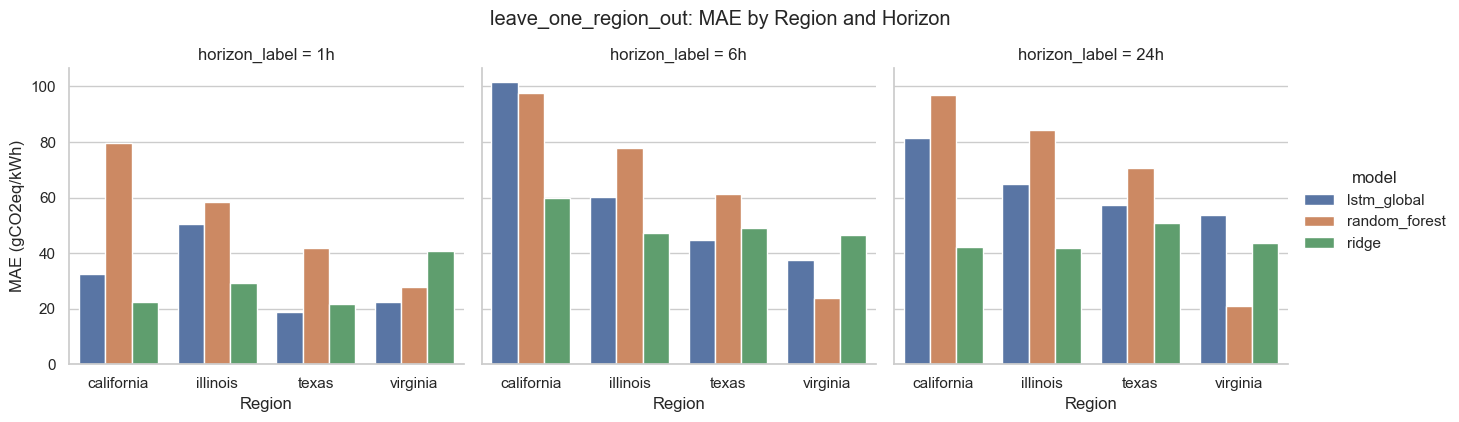

In [11]:
region_metrics = metrics[metrics["region"] != "macro_average"].copy()
if not region_metrics.empty:
    for split_type in sorted(region_metrics["split_type"].unique()):
        viz = region_metrics[region_metrics["split_type"] == split_type]
        g = sns.catplot(
            data=viz,
            x="region",
            y="MAE",
            hue="model",
            col="horizon_label",
            kind="bar",
            height=4,
            aspect=1.1,
        )
        g.set_axis_labels("Region", f"MAE ({UNIT})")
        g.fig.suptitle(f"{split_type}: MAE by Region and Horizon", y=1.05)
        plt.show()


## Graph: Regional Generalization Gap


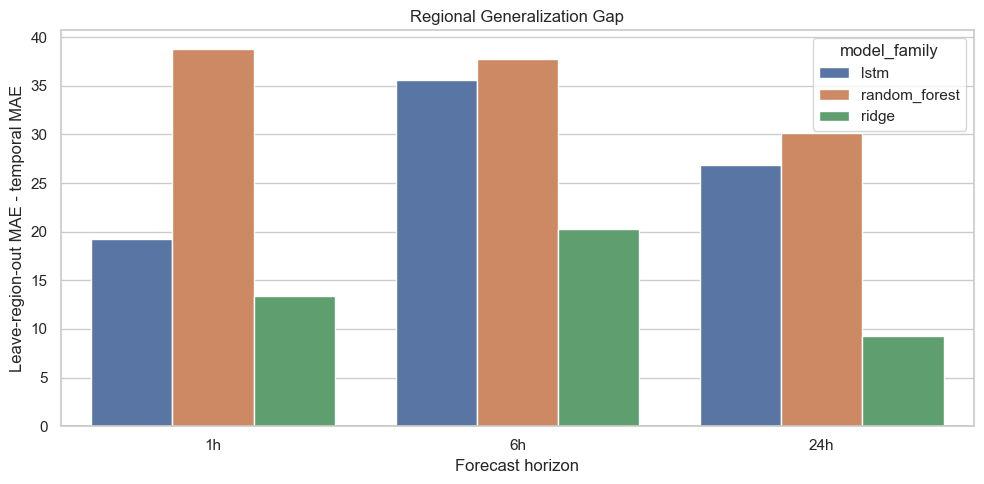

In [12]:
if not macro_gaps.empty:
    macro_gaps["horizon_label"] = macro_gaps["horizon"].astype(str) + "h"
    plt.figure(figsize=(10, 5))
    sns.barplot(data=macro_gaps, x="horizon_label", y="region_gap", hue="model_family")
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Regional Generalization Gap")
    plt.ylabel("Leave-region-out MAE - temporal MAE")
    plt.xlabel("Forecast horizon")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping gap plot until comparable temporal and regional rows exist.")


## Graph: Predicted vs Actual


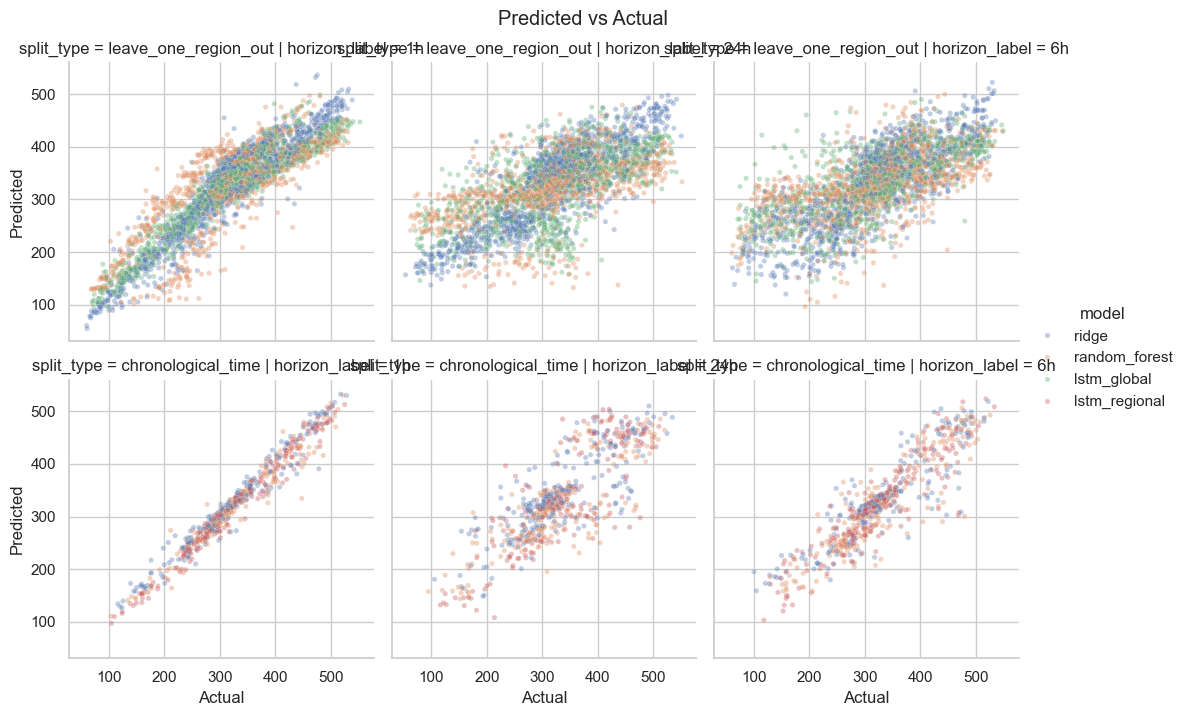

In [13]:
sample = predictions.sample(min(12000, len(predictions)), random_state=42)
sample["horizon_label"] = sample["horizon"].astype(str) + "h"
g = sns.relplot(
    data=sample,
    x="y_true",
    y="y_pred",
    hue="model",
    col="horizon_label",
    row="split_type",
    alpha=0.35,
    s=14,
    height=3.5,
)
g.set_axis_labels("Actual", "Predicted")
g.fig.suptitle("Predicted vs Actual", y=1.02)
plt.show()


## Graph: Residual Distribution


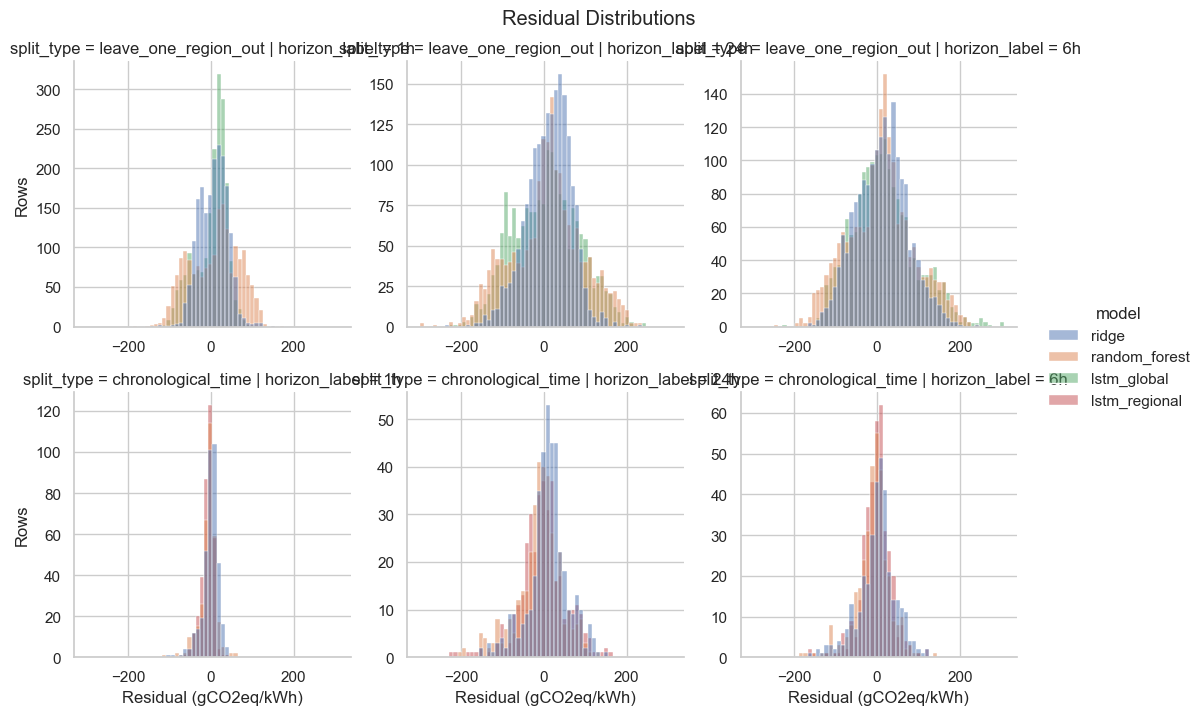

In [14]:
residuals = predictions.copy()
residuals["residual"] = residuals["y_pred"] - residuals["y_true"]
residuals["horizon_label"] = residuals["horizon"].astype(str) + "h"
residuals = residuals.sample(min(20000, len(residuals)), random_state=42)

g = sns.displot(
    data=residuals,
    x="residual",
    hue="model",
    col="horizon_label",
    row="split_type",
    bins=60,
    height=3.5,
    facet_kws={"sharex": False, "sharey": False},
)
g.set_axis_labels(f"Residual ({UNIT})", "Rows")
g.fig.suptitle("Residual Distributions", y=1.02)
plt.show()


## Graph: Actual vs Predicted Time-Series Examples


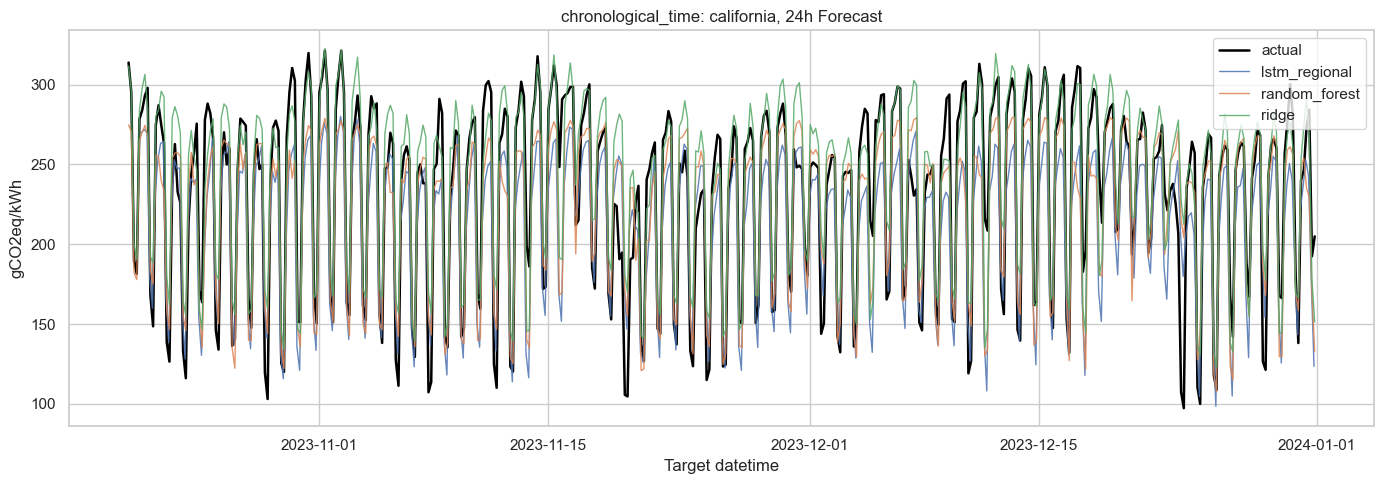

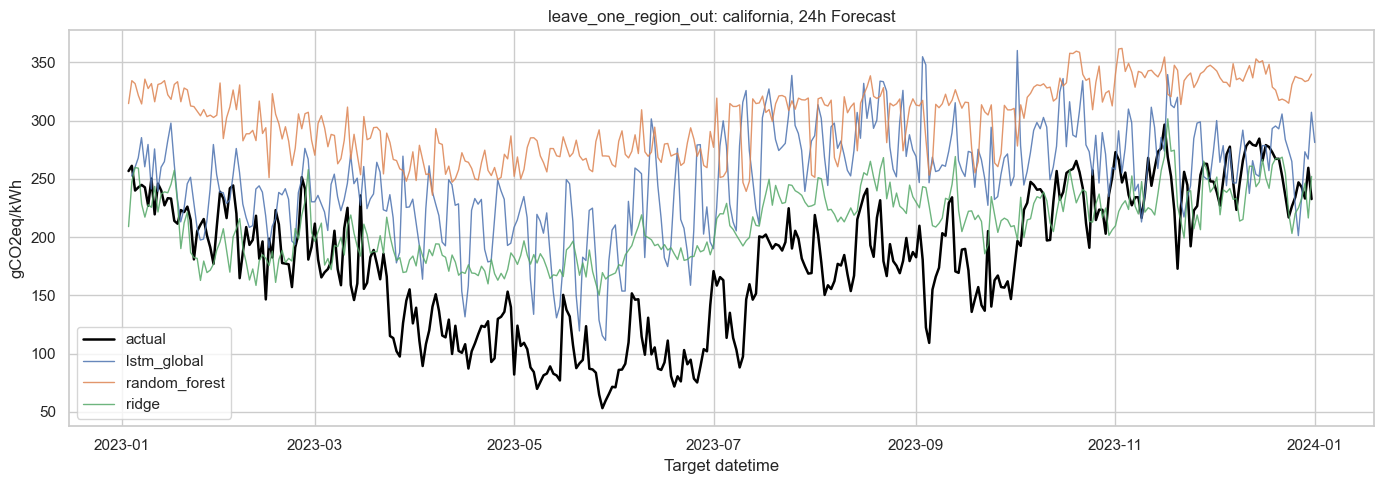

In [15]:
for split_type in sorted(predictions["split_type"].unique()):
    split_data = predictions[predictions["split_type"] == split_type].copy()
    if split_data.empty:
        continue
    horizon = max(split_data["horizon"].unique())
    region = sorted(split_data["region"].unique())[0]
    viz = split_data[(split_data["horizon"] == horizon) & (split_data["region"] == region)].sort_values("target_datetime")
    if viz.empty:
        continue

    plt.figure(figsize=(14, 5))
    actual = viz.drop_duplicates(["target_datetime", "region", "horizon"])
    step = max(1, len(actual) // 350)
    plt.plot(actual["target_datetime"].iloc[::step], actual["y_true"].iloc[::step], color="black", linewidth=1.8, label="actual")

    for model_name, model_frame in viz.groupby("model"):
        step = max(1, len(model_frame) // 350)
        plt.plot(model_frame["target_datetime"].iloc[::step], model_frame["y_pred"].iloc[::step], linewidth=1, alpha=0.85, label=model_name)

    plt.title(f"{split_type}: {region}, {horizon}h Forecast")
    plt.ylabel(UNIT)
    plt.xlabel("Target datetime")
    plt.legend()
    plt.tight_layout()
    plt.show()
